# Mental Health and Academic Performance Predictor

This notebook analyzes how college students' mental health, discipline, sleep, and screen-time habits relate to GPA. It walks through:

1. **Data loading & cleaning** (`DataPipeline`)
2. **Dataset summary** (`data_summary`)
3. **Exploratory Data Analysis** (`data_eda`)
4. **Model training & evaluation** (`ModelTrainer`)
5. **Interactive GPA prediction**

> **Setup:** Download the dataset from Kaggle, rename the CSV to `students.csv`, and place it in the `data/` folder before running.
>
> Dataset URL: https://www.kaggle.com/datasets/sharmajicoder/college-students-habits-and-performance

## 0. Imports & Setup

In [1]:
# Standard library
import math
import itertools
from functools import reduce

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project modules
from data_pipeline import DataPipeline, FEATURE_COLUMNS, TARGET_COLUMN
from data_summary import print_data_summary
from data_eda import run_eda
from model_trainer import ModelTrainer
from utils import find_missing_columns

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
print("All modules imported successfully.")

All modules imported successfully.


## 1. Load & Clean the Data

In [2]:
# Instantiate the pipeline — one of the two required classes.
# DataPipeline composes with ModelTrainer (composition relationship).
pipeline = DataPipeline(csv_path="data/students.csv")

# Exception-handling scenario 1: missing CSV file
try:
    df = pipeline.clean()
except FileNotFoundError as e:
    print(f"[ERROR] {e}")
    raise

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns after cleaning.")
df.head(3)

Loaded 998,442 rows x 42 columns after cleaning.


,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa,performance_level
0,3.014684,67.00599,51.595387,57.211285,61.653540,65.397200,4,5.993893,4.287966,58.14600,...,0,1.958940,73.727480,5.721128,3.587111,2.814086,1.814086,5.491878,0.546729,Low
1,3.665277,73.28455,69.749020,57.552320,62.062782,65.715500,3,6.949383,1.841224,41.94529,...,0,3.146447,48.468456,5.755232,4.820090,2.836821,1.836821,2.876881,0.707133,Low
2,2.703784,72.32519,92.837640,44.568970,46.482760,53.597702,2,6.703293,3.863112,56.55575,...,1,5.551245,46.623684,4.456897,5.493774,1.971265,0.971265,5.704047,0.868230,Low


## 2. Dataset Summary

In [3]:
print_data_summary()

Student Data Summary
--------------------
Rows: 998442
Columns: 42

Column names:
study_hours
attendance
assignment_completion
midterm_score
final_score
project_score
backlogs
sleep_hours
stress
anxiety
depression
motivation
concentration
time_management
self_discipline
social_media_hours
gaming_hours
netflix_hours
screen_time
physical_activity
junk_food_frequency
caffeine_mg
late_night_frequency
procrastination_score
family_income
parental_education_level
internet_quality
library_visits
online_courses_completed
part_time_hours
peer_study_group
relationship_status
hostel_student
extracurricular_hours
phone_unlocks_per_day
previous_gpa
class_participation
weekly_study_sessions
group_study_hours
financial_stress
gpa
performance_level

Missing values:
study_hours                 0
attendance                  0
assignment_completion       0
midterm_score               0
final_score                 0
project_score               0
backlogs                    0
sleep_hours                 0
s

## 3. Feature & Target Split

In [4]:
# Exception-handling scenario 2: schema mismatch (missing required columns)
try:
    X, y = pipeline.get_features_and_target()
except ValueError as e:
    print(f"[ERROR] {e}")
    raise

print(f"Features : {X.shape[1]} columns")
print(f"Target   : '{y.name}' — range [{y.min():.3f}, {y.max():.3f}]")

Features : 14 columns
Target   : 'gpa' — range [0.000, 2.009]


## 4. Exploratory Data Analysis

Correlation with GPA (strongest first):

  previous_gpa                        +0.780
  concentration                       +0.715
  motivation                          +0.640
  time_management                     +0.622
  self_discipline                     +0.622
  procrastination_score               -0.571
  sleep_hours                         +0.385
  phone_unlocks_per_day               -0.334
  screen_time                         -0.333
  late_night_frequency                -0.333
  financial_stress                    -0.158
  stress                              -0.047
  depression                          -0.002
  anxiety                             -0.002


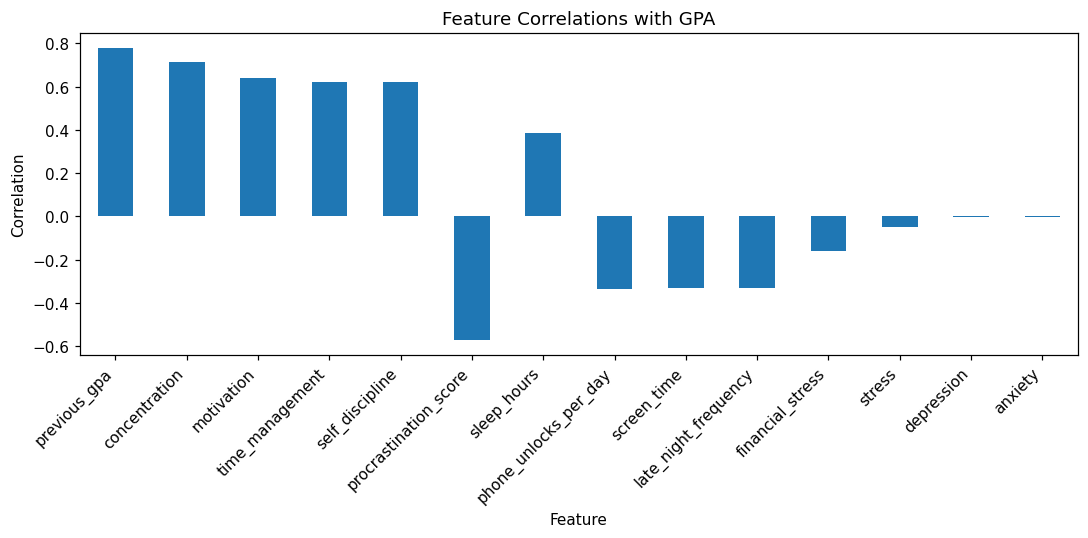

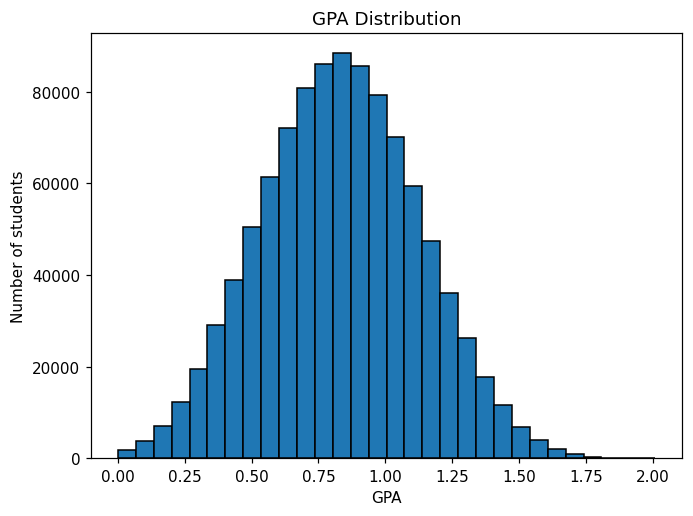

In [5]:
# Calls run_eda() from data_eda.py — prints correlations and shows both charts
run_eda(X, y)

In [6]:
# List comprehension (Part 2 requirement)
df_num = pd.concat([X, y], axis=1).select_dtypes(include="number")
correlations = df_num.corr()["gpa"].drop("gpa").sort_values(key=abs, ascending=False)

strong_predictors = [feat for feat, r in correlations.items() if abs(r) > 0.3]
print("Features with |r| > 0.3:", strong_predictors)

Features with |r| > 0.3: ['previous_gpa', 'concentration', 'motivation', 'time_management', 'self_discipline', 'procrastination_score', 'sleep_hours', 'phone_unlocks_per_day', 'screen_time', 'late_night_frequency']


In [7]:
# Generator function (Part 2 requirement)
def feature_stats_generator(dataframe):
    """Yield (feature_name, mean, std) tuples one at a time."""
    for col in dataframe.columns:
        yield col, dataframe[col].mean(), dataframe[col].std()

print(f"{'Feature':<35} {'Mean':>8} {'Std':>8}")
print("-" * 55)
for name, mean, std in feature_stats_generator(X):
    print(f"{name:<35} {mean:>8.3f} {std:>8.3f}")

Feature                                 Mean      Std
-------------------------------------------------------
stress                                 3.209    1.755
anxiety                               49.966   14.993
depression                            44.971   14.984
motivation                             6.005    0.971
concentration                          6.007    1.092
time_management                        6.004    0.997
self_discipline                        6.004    0.997
procrastination_score                  5.000    1.655
financial_stress                       4.996    1.339
sleep_hours                            6.501    0.435
late_night_frequency                   2.008    0.979
screen_time                            7.030    3.426
phone_unlocks_per_day                 60.039   19.869
previous_gpa                           6.005    1.493


In [8]:
# Set operations (Part 2 requirement)
# Mutable type: set; immutable types: strings inside the set
all_features: set = set(X.columns)
high_correlation_features: set = set(strong_predictors)
low_correlation_features = all_features - high_correlation_features

print("Total features    :", len(all_features))
print("High |r| (> 0.3)  :", high_correlation_features)
print("Low  |r| (<= 0.3) :", low_correlation_features)

Total features    : 14
High |r| (> 0.3)  : {'concentration', 'sleep_hours', 'procrastination_score', 'time_management', 'self_discipline', 'late_night_frequency', 'screen_time', 'previous_gpa', 'motivation', 'phone_unlocks_per_day'}
Low  |r| (<= 0.3) : {'stress', 'depression', 'financial_stress', 'anxiety'}


In [9]:
# reduce() and lambda (Part 2 requirement)
# Cumulative sum of individual R² values
r_squared_values: list = [r ** 2 for r in correlations.values]  # list (mutable)
cumulative_r2 = reduce(lambda acc, v: acc + v, r_squared_values, 0.0)

# Tuple (immutable)
summary_tuple: tuple = ("cumulative_r2", round(cumulative_r2, 4))
print(f"Sum of individual R² values: {summary_tuple}")

Sum of individual R² values: ('cumulative_r2', np.float64(3.1381))


## 5. Model Training

In [10]:
# ModelTrainer is the second required class.
# It receives a DataPipeline — this is the composition relationship.
trainer = ModelTrainer(pipeline)

# __str__ and __len__ operator overload demos
print(trainer)
print(f"Training rows: {len(trainer)}")

model = trainer.train()
print("\nModel trained successfully.")

ModelTrainer(model=LinearRegression, training_rows=798753)
Training rows: 798753



Model trained successfully.

## 6. Model Evaluation

In [11]:
metrics = trainer.evaluate()

Coefficient table:
              feature  coefficient         t_stat       p_value
            intercept    -1.030285      -6.650571  2.919587e-11
               stress    -0.063835    -112.052846  0.000000e+00
              anxiety     0.002563       1.138645  2.548514e-01
           depression     0.001861       1.161546  2.454199e-01
           motivation     0.097974       2.078760  3.763945e-02
        concentration     0.032882       3.609460  3.068347e-04
      time_management    -0.012428      -0.526834  5.983088e-01
      self_discipline    -0.012428      -0.526834  5.983088e-01
procrastination_score    -0.014865      -4.137799  3.506536e-05
     financial_stress     0.000015       0.064079  9.489072e-01
          sleep_hours     0.091085       6.008901  1.867852e-09
 late_night_frequency   -87.726636 -201438.390022  0.000000e+00
          screen_time    25.082621   16455.265494  0.000000e+00
phone_unlocks_per_day    -0.003361      -5.693891  1.241767e-08
         previous_gpa

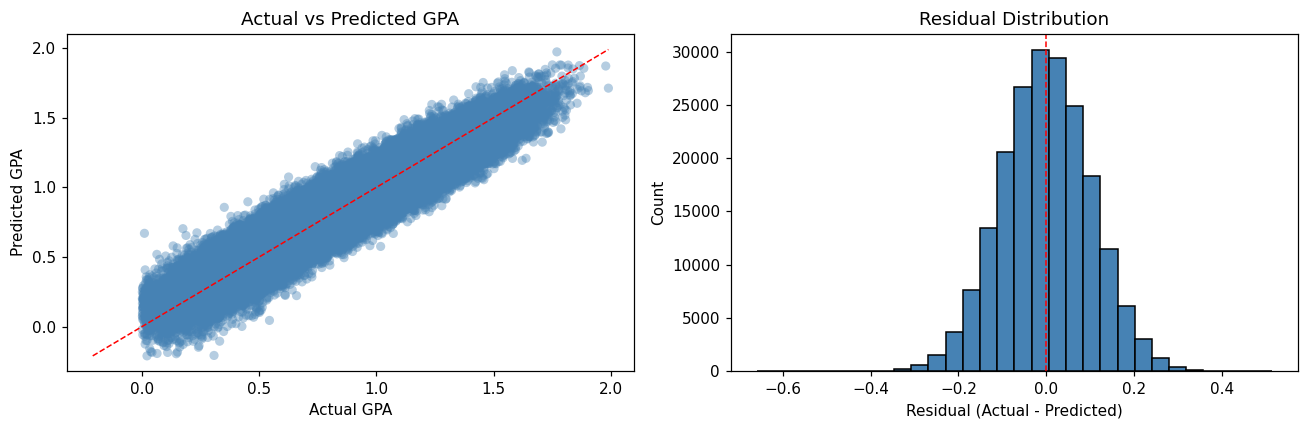

In [12]:
# Residual plots
predictions = trainer.predict(trainer.X_test)
residuals = trainer.y_test - predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs actual
axes[0].scatter(trainer.y_test, predictions, alpha=0.4, color="steelblue", edgecolors="none")
lims = [min(trainer.y_test.min(), predictions.min()),
        max(trainer.y_test.max(), predictions.max())]
axes[0].plot(lims, lims, "--", color="red", linewidth=1)
axes[0].set_xlabel("Actual GPA")
axes[0].set_ylabel("Predicted GPA")
axes[0].set_title("Actual vs Predicted GPA")

# Residual distribution
axes[1].hist(residuals, bins=30, edgecolor="black", color="steelblue")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

In [13]:
# enumerate() and zip() (Part 2 requirement)
coef_pairs = list(zip(FEATURE_COLUMNS, model.coef_))
coef_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

print("Top 5 most influential features (by |coefficient|):")
for rank, (feat, coef) in enumerate(coef_pairs[:5], start=1):
    direction = "up GPA" if coef > 0 else "down GPA"
    print(f"  {rank}. {feat:<35} coef = {coef:+.4f}  ({direction})")

Top 5 most influential features (by |coefficient|):
  1. late_night_frequency                coef = -87.7266  (down GPA)
  2. screen_time                         coef = +25.0826  (up GPA)
  3. previous_gpa                        coef = +0.1295  (up GPA)
  4. motivation                          coef = +0.0980  (up GPA)
  5. sleep_hours                         coef = +0.0911  (up GPA)


In [14]:
# map() (Part 2 requirement)
top3 = [feat for feat, _ in coef_pairs[:3]]
top3_upper = list(map(lambda c: c.upper(), top3))
print("Top 3 features (uppercased via map):", top3_upper)

Top 3 features (uppercased via map): ['LATE_NIGHT_FREQUENCY', 'SCREEN_TIME', 'PREVIOUS_GPA']


In [15]:
# itertools built-in library (Part 2 requirement)
print("All pairs from top-3 features (itertools.combinations):")
for pair in itertools.combinations(top3, 2):
    print(" ", pair)

All pairs from top-3 features (itertools.combinations):
  ('late_night_frequency', 'screen_time')
  ('late_night_frequency', 'previous_gpa')
  ('screen_time', 'previous_gpa')


## 7. Predict GPA for a Custom Student

Edit the values below and re-run to get an instant GPA prediction.

In [16]:
# Dict (mutable) with number and string values (immutable)
student_profile: dict = {
    "stress"                : 5,
    "anxiety"               : 4,
    "depression"            : 3,
    "motivation"            : 7,
    "concentration"         : 7,
    "time_management"       : 7,
    "self_discipline"       : 8,
    "procrastination_score" : 3,
    "financial_stress"      : 4,
    "sleep_hours"           : 7,
    "late_night_frequency"  : 2,
    "screen_time"           : 4,
    "phone_unlocks_per_day" : 50,
    "previous_gpa"          : 7.5,
}

# Exception-handling scenario 3: invalid input values
try:
    if not (0 <= student_profile["sleep_hours"] <= 24):
        raise ValueError("sleep_hours must be between 0 and 24.")
    if not (0 <= student_profile["previous_gpa"] <= 10):
        raise ValueError("previous_gpa must be between 0 and 10.")
except ValueError as e:
    print(f"[INPUT ERROR] {e}")
    raise

student_df = pd.DataFrame([student_profile])[FEATURE_COLUMNS]
predicted_gpa = trainer.predict(student_df).iloc[0]

print(f"Predicted GPA : {predicted_gpa:.3f}")
print(f"Dataset range : {y.min():.3f} - {y.max():.3f}")

Predicted GPA : -74.331
Dataset range : 0.000 - 2.009


## 8. Run Tests

In [17]:
import subprocess
result = subprocess.run(
    ["pytest", "-v", "test_data_pipeline.py", "test_model_trainer.py"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

============================= test session starts =============================
platform win32 -- Python 3.13.7, pytest-9.0.3, pluggy-1.6.0 -- C:\Python313\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\Matthew Feroz\Desktop\College\Spring 2026\Min Song - Python\Engineering-Programming-Python
plugins: anyio-4.12.1
collecting ... collected 7 items

test_data_pipeline.py::test_load_students_file PASSED                    [ 14%]
test_data_pipeline.py::test_clean_students_file PASSED                   [ 28%]
test_data_pipeline.py::test_missing_students_file PASSED                 [ 42%]
test_data_pipeline.py::test_get_features_and_target PASSED               [ 57%]
test_data_pipeline.py::test_get_features_and_target_missing_column PASSED [ 71%]
test_model_trainer.py::test_model_trainer_trains_and_predicts PASSED     [ 85%]
test_model_trainer.py::test_model_trainer_len_counts_training_rows PASSED [100%]

============================== 7 passed in 1.00s ==============================



## 9. `__name__` Guard Demo (Part 2)

All `.py` modules use `if __name__ == "__main__":` so they can be imported without side effects and also run standalone. The same pattern is demonstrated here:

In [18]:
if __name__ == "__main__":
    print("Running as main — mirrors the guard used in all .py modules.")

Running as main — mirrors the guard used in all .py modules.
